# SMAL Colab Demo

An end-to-end, single-run demo of **Short-term Memory Active Learning (SMAL)** for molecular property prediction. Upload this notebook to Google Colab and run cells top-to-bottom.

By default the demo runs **SMAL on the `pgp_broccatelli` dataset** with RandomForest/Morgan, seed `0`, error rate `0`, and the `min_oob_error` forget rule. Change the parameters in the **Parameters** cell to reproduce any of the runs defined in [`scripts/`](scripts).


## 1. Install dependencies

We pin **MolALKit v1.2.0**, the exact version used to generate all manuscript results.


In [2]:
%pip install -q molalkit==1.2.0 git+https://gitlab.com/Xiangyan93/graphdot.git@v0.9.0 pandas matplotlib seaborn


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 

## 2. Imports and working directory


In [3]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from molalkit.data.datasets import DATA_DIR
from molalkit.exe.run import molalkit_run

sns.set_theme(style="ticks", context="notebook")

WORKDIR = Path("/content/smal_demo")
OUTPUT_DIR = WORKDIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Working directory:", WORKDIR)
print("MolALKit data dir:", DATA_DIR)


Working directory: /content/smal_demo
MolALKit data dir: /usr/local/lib/python3.12/dist-packages/molalkit/data/datasets


## 3. Parameters

These are the parameters varied in the manuscript benchmark (`scripts/<dataset>-rf_morgan-<learning_type>.sh`). Edit the values below to pick a single run.


In [4]:
# === Choose one of the 6 manuscript datasets ===
# Allowed: "ames", "CYP2D6_Veith", "CYP3A4_Veith", "MDR1_MDCK_classification2", "PAMPA_NCATS", "pgp_broccatelli"
DATASET = "pgp_broccatelli"

# === Model ===
# Allowed: "RandomForest_Morgan_Config" (only model used in results-initial)
MODEL = "RandomForest_Morgan_Config"

# === Learning strategy ===
# Allowed:
#   "al"   -- Active learning (explorative selection)
#   "pl"   -- Passive learning (random selection)
#   "smal" -- Short-term Memory Active Learning (AL + forgetting)
LEARNING_TYPE = "smal"

# === Random seed ===
# Manuscript sweeps seeds 0..19 for each (dataset, error_rate, learning_type, forget_method).
SEED = 0

# === Label-noise rate (fraction of training labels flipped) ===
# Manuscript sweeps {0.0, 0.1, 0.2, 0.3, 0.4}.
ERROR_RATE = 0.0

# === Forget method (SMAL only; ignored for AL/PL) ===
# Allowed: "random", "first", "max_oob_error", "min_oob_error",
#          "max_oob_uncertainty", "min_oob_uncertainty"
FORGET_METHOD = "min_oob_error"

# === Split (fixed for results-initial) ===
SPLIT_TYPE = "scaffold_random"
SPLIT_SIZES = (0.5, 0.5)

# === Per-(dataset, error) SMAL bookkeeping from f_min_train_size.csv ===
# (f_min_train_size per error rate, max_iter)
SMAL_PARAMS = {
    "ames":                      ({0.0: 2938, 0.1: 2971, 0.2: 2753, 0.3: 2391, 0.4: 2881}, 3636),
    "CYP2D6_Veith":              ({0.0: 1485, 0.1: 2070, 0.2: 2710, 0.3: 4272, 0.4: 4069}, 6562),
    "CYP3A4_Veith":              ({0.0: 4514, 0.1: 5196, 0.2: 5416, 0.3: 4636, 0.4: 3902}, 6161),
    "MDR1_MDCK_classification2": ({0.0: 682,  0.1: 711,  0.2: 831,  0.3: 974,  0.4: 938 }, 1106),
    "PAMPA_NCATS":               ({0.0: 420,  0.1: 642,  0.2: 641,  0.3: 888,  0.4: 780 }, 1014),
    "pgp_broccatelli":           ({0.0: 317,  0.1: 350,  0.2: 350,  0.3: 386,  0.4: 408 }, 606),
}

# === Datasets that need explicit --data_path/--smiles_columns/--targets_columns/--task_type ===
DATA_PATH_DATASETS = {"PAMPA_NCATS", "MDR1_MDCK_classification2"}

assert LEARNING_TYPE in {"al", "pl", "smal"}
assert DATASET in SMAL_PARAMS
assert ERROR_RATE in SMAL_PARAMS[DATASET][0]


## 4. Build the `molalkit_run` argument list

This block constructs the same CLI arguments used by `scripts/<dataset>-rf_morgan-<learning_type>.sh`, but as a Python list so we can call `molalkit_run` directly in-process.


In [5]:
def reset_dir(path: Path) -> Path:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

subdir = {"al": "active_learning", "pl": "passive_learning", "smal": "smal"}[LEARNING_TYPE]
if LEARNING_TYPE == "smal":
    run_name = f"smal-{DATASET}-{int(ERROR_RATE*100)}-{FORGET_METHOD}-{SEED}"
else:
    run_name = f"{LEARNING_TYPE}-{DATASET}-{int(ERROR_RATE*100)}-{SEED}"
save_dir = reset_dir(OUTPUT_DIR / subdir / run_name)

# Data flags
if DATASET in DATA_PATH_DATASETS:
    data_flags = [
        "--data_path", str(Path(DATA_DIR) / f"{DATASET}.csv"),
        "--smiles_columns", "SMILES",
        "--targets_columns", "Y",
        "--task_type", "binary",
    ]
else:
    data_flags = ["--data_public", DATASET]

select_method = "random" if LEARNING_TYPE == "pl" else "explorative"

args = [
    *data_flags,
    "--metrics", "roc_auc", "accuracy", "balanced_accuracy", "precision", "recall", "f1_score", "mcc",
    "--model_configs", MODEL,
    "--split_type", SPLIT_TYPE,
    "--split_sizes", str(SPLIT_SIZES[0]), str(SPLIT_SIZES[1]),
    "--evaluate_stride", "1",
    "--n_jobs", "2",
    "--seed", str(SEED),
    "--error_rate", str(ERROR_RATE),
    "--select_method", select_method,
    "--save_dir", str(save_dir),
]

if LEARNING_TYPE == "smal":
    fmin_map, max_iter = SMAL_PARAMS[DATASET]
    args += [
        "--forget_method", FORGET_METHOD,
        "--n_forget", "1",
        "--f_min_train_size", str(fmin_map[ERROR_RATE]),
        "--max_iter", str(max_iter),
    ]

print("Run name:", run_name)
print("Save dir:", save_dir)
print("\nmolalkit_run arguments:")
print("  " + " ".join(args))


Run name: smal-pgp_broccatelli-0-min_oob_error-0
Save dir: /content/smal_demo/outputs/smal/smal-pgp_broccatelli-0-min_oob_error-0

molalkit_run arguments:
  --data_public pgp_broccatelli --metrics roc_auc accuracy balanced_accuracy precision recall f1_score mcc --model_configs RandomForest_Morgan_Config --split_type scaffold_random --split_sizes 0.5 0.5 --evaluate_stride 1 --n_jobs 2 --seed 0 --error_rate 0.0 --select_method explorative --save_dir /content/smal_demo/outputs/smal/smal-pgp_broccatelli-0-min_oob_error-0 --forget_method min_oob_error --n_forget 1 --f_min_train_size 317 --max_iter 606


## 5. Run

**Heads-up:** the manuscript-grade `max_iter` (e.g. 606 for `pgp_broccatelli`) takes a long time on a Colab CPU. For a quick smoke run, override `--max_iter` to something small (e.g. 30) in the cell below before calling `molalkit_run`.


In [9]:
# Optional: cap iterations for a fast Colab smoke run.
QUICK_RUN_MAX_ITER = 606   # set to None to use the manuscript value
if QUICK_RUN_MAX_ITER is not None:
    if "--max_iter" in args:
        i = args.index("--max_iter")
        args[i + 1] = str(QUICK_RUN_MAX_ITER)
    else:
        args += ["--max_iter", str(QUICK_RUN_MAX_ITER)]
    print(f"Capped --max_iter at {QUICK_RUN_MAX_ITER} for a fast demo run.")

molalkit_run(args)
print("\nRun complete.")


Capped --max_iter at 606 for a fast demo run.


100%|██████████| 1218/1218 [00:00<00:00, 1917.47it/s]
Total scaffolds = 682 | 
split 0 scaffolds = 355 | 
split 1 scaffolds = 327 | 
Start active learning from scratch
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done 1146 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 1218 out of 1218 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done 1146 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 1209 out of 1212 | elapsed:    0.5s remaining:    0.0s
[Parallel(n_jobs=2)]: Done 1212 out of 1212 | elapsed:    0.5s finished
Active learning loop 0
Active learning loop 1
Active learning loop 2
Active learning loop 3
Active learning loop 4
Active learning loop 5
Active learning loop 6
Active learning loop 7
Active learning loop 8
Active learning loop 9
Active learning loop 10
Active learning loop 11
Active learning loop 12
Active learning loop 13
Active


Run complete.


## 6. Inspect outputs


In [10]:
print("Files in save_dir:")
for p in sorted(save_dir.iterdir()):
    print(" ", p.name)

traj = pd.read_csv(save_dir / "al_traj.csv")
traj.tail()


Files in save_dir:
  al_traj.csv
  alb_output_debug.log
  full.csv
  pool_end.csv
  pool_init.csv
  train_end.csv
  train_init.csv
  val.csv


,n_iter,roc_auc-model_0,accuracy-model_0,balanced_accuracy-model_0,precision-model_0,recall-model_0,f1_score-model_0,mcc-model_0,uidx_before,uidx_select,acquisition_select,uidx_forget,acquisition_forget,uidx_after
894,893,0.926101,0.850575,0.856710,0.915094,0.819718,0.864785,0.704232,"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1...",[],[],[83],[0.1],"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1..."
895,894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1...",[249],[0.96],[],[],"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1..."
896,895,0.914961,0.806240,0.823722,0.934066,0.718310,0.812102,0.641922,"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1...",[],[],[616],[0.09375],"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1..."
897,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1...",[58],[0.8976],[],[],"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1..."
898,897,0.920467,0.842365,0.847987,0.905956,0.814085,0.857567,0.687116,"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1...",[],[],[244],[0.06666666666666667],"[210, 320, 260, 427, 542, 770, 477, 202, 39, 1..."


## 7. Plot the learning trajectory


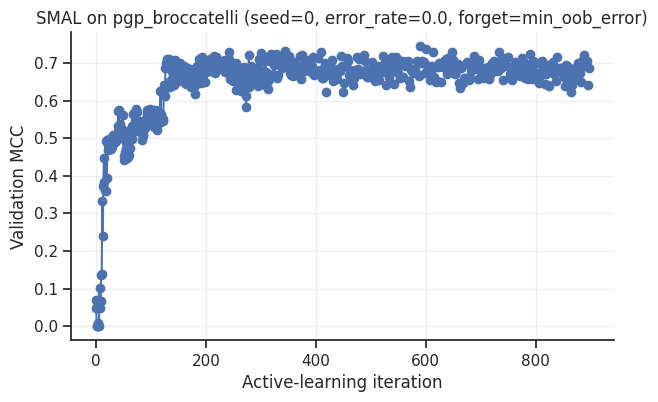

In [11]:
metric_col = next(c for c in traj.columns if c.startswith("mcc-model"))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(traj["n_iter"], traj[metric_col], marker="o")
ax.set_xlabel("Active-learning iteration")
ax.set_ylabel("Validation MCC")
ax.set_title(f"{LEARNING_TYPE.upper()} on {DATASET} (seed={SEED}, error_rate={ERROR_RATE}"
             + (f", forget={FORGET_METHOD})" if LEARNING_TYPE == "smal" else ")"))
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.show()


## 8. Next steps

- Change `LEARNING_TYPE` to `"al"` or `"pl"` and rerun for a head-to-head baseline.
- Loop over `FORGET_METHOD` values to compare SMAL forgetting strategies.
- Loop over `SEED` 0..19 and aggregate trajectories for confidence intervals (this is what `scripts/<dataset>-rf_morgan-smal.sh` does).
- Swap `DATASET` for any of the six manuscript datasets — the parameter table in cell 3 already pins the correct `f_min_train_size` and `max_iter` for each.
